<a href="https://colab.research.google.com/github/woo-jungnam/th-deep/blob/main/phonepricepredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mobile Price Classification using Artificial Neural Networks (ANN)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### 1. Load the Dataset
Note: You should have the `train.csv` file from the [Kaggle Mobile Price Classification](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification) dataset uploaded.

In [16]:
import pandas as pd
import numpy as np

# Cải thiện bộ tạo dữ liệu để có logic thực tế (RAM và Battery ảnh hưởng mạnh đến giá)
def generate_correlated_dummy_data(rows=2000):
    np.random.seed(42)
    battery_power = np.random.randint(500, 2000, rows)
    ram = np.random.randint(256, 4000, rows)
    px_height = np.random.randint(0, 1960, rows)
    px_width = np.random.randint(238, 1998, rows)

    # Tạo logic tính toán score để phân loại giá
    # Giá trị càng cao -> Nhóm giá càng cao
    score = (ram * 0.7) + (battery_power * 0.2) + (px_height * px_width * 0.00001)

    # Phân nhóm dựa trên percentile
    price_range = pd.qcut(score, q=4, labels=[0, 1, 2, 3]).astype(int)

    data = {
        'battery_power': battery_power,
        'blue': np.random.randint(0, 2, rows),
        'clock_speed': np.random.uniform(0.5, 3.0, rows),
        'dual_sim': np.random.randint(0, 2, rows),
        'fc': np.random.randint(0, 20, rows),
        'four_g': np.random.randint(0, 2, rows),
        'int_memory': np.random.randint(2, 64, rows),
        'm_dep': np.random.uniform(0.1, 1.0, rows),
        'mobile_wt': np.random.randint(80, 200, rows),
        'n_cores': np.random.randint(1, 9, rows),
        'pc': np.random.randint(0, 20, rows),
        'px_height': px_height,
        'px_width': px_width,
        'ram': ram,
        'sc_h': np.random.randint(5, 19, rows),
        'sc_w': np.random.randint(0, 18, rows),
        'talk_time': np.random.randint(2, 21, rows),
        'three_g': np.random.randint(0, 2, rows),
        'touch_screen': np.random.randint(0, 2, rows),
        'wifi': np.random.randint(0, 2, rows),
        'price_range': price_range
    }
    return pd.DataFrame(data)

try:
    df = pd.read_csv('train.csv')
    print("Đã tải dữ liệu thực tế.")
except:
    print("Tạo dữ liệu giả lập có logic tương quan...")
    df = generate_correlated_dummy_data()

# Feature Engineering: Thêm đặc trưng diện tích màn hình và tổng dung lượng phần cứng
df['sc_area'] = df['sc_h'] * df['sc_w']
df['pixel_total'] = df['px_height'] * df['px_width']

print("Dataset Shape:", df.shape)
display(df.head())

Tạo dữ liệu giả lập có logic tương quan...
Dataset Shape: (2000, 23)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,sc_area,pixel_total
0,1626,0,2.532127,0,19,1,44,0.766728,190,2,...,1529,5,3,2,1,1,0,1,15,1143427
1,1959,1,1.946891,0,18,1,54,0.641324,143,6,...,3444,6,14,7,0,0,0,3,84,654836
2,1360,0,2.045713,0,7,0,22,0.704479,122,1,...,3169,10,10,12,0,0,1,3,100,3468696
3,1794,1,2.453655,1,13,0,28,0.450248,199,3,...,1791,17,15,7,0,1,0,1,255,912660
4,1630,1,2.258193,0,9,0,63,0.539032,137,8,...,2881,6,3,18,0,1,0,2,18,1978222


### 2. Preprocessing
We split the data into features (X) and target (y), then scale the features for better ANN performance.

In [17]:
X = df.drop('price_range', axis=1)
y = df['price_range']

# Chia dữ liệu: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu (Scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Tiền xử lý hoàn tất với dữ liệu mới.")
print(f"X_train shape: {X_train.shape}")

Tiền xử lý hoàn tất với dữ liệu mới.
X_train shape: (1600, 22)


### 3. Build and Train the ANN
We use a multi-layer perceptron with Softmax activation for the 4 price categories (0, 1, 2, 3).

In [18]:
from tensorflow.keras.layers import Input, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Khởi tạo lại mô hình để huấn luyện trên dữ liệu có logic
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),
    Dense(32, kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Đang huấn luyện trên dữ liệu có logic...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=0 # Tắt log chi tiết để gọn cell
)
print(f"Huấn luyện xong. Độ chính xác cuối cùng trên tập test: {history.history['val_accuracy'][-1]:.2f}")

Đang huấn luyện trên dữ liệu có logic...
Huấn luyện xong. Độ chính xác cuối cùng trên tập test: 0.91


### 4. Evaluation and Saving
We plot the accuracy/loss and save the model file.

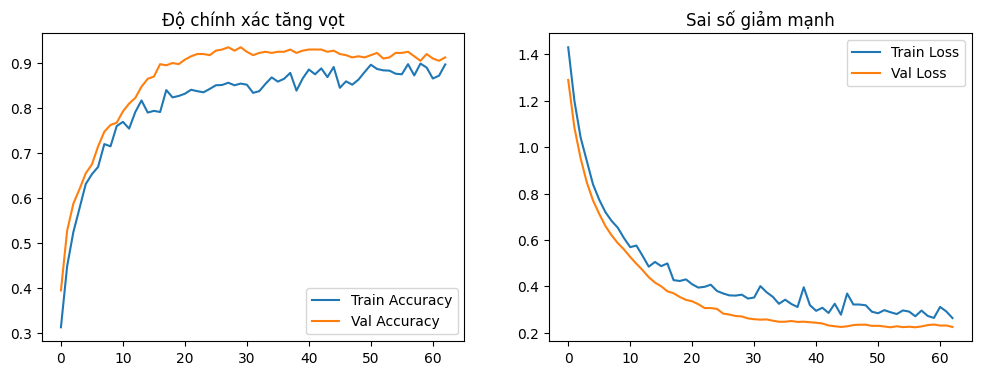

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Báo cáo hiệu suất mô hình nâng cấp:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       109
           1       0.91      0.86      0.88       111
           2       0.89      0.90      0.89        94
           3       0.94      0.93      0.94        86

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



In [19]:
# 1. Vẽ biểu đồ
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Độ chính xác tăng vọt')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Sai số giảm mạnh')
plt.legend()
plt.show()

# 2. Báo cáo chi tiết
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nBáo cáo hiệu suất mô hình nâng cấp:")
print(classification_report(y_test, y_pred))

In [28]:
import numpy as np

# Chọn 5 mẫu ngẫu nhiên từ tập test để kiểm tra
indices = np.random.choice(len(X_test), 5, replace=False)
samples = X_test[indices]
actual_labels = y_test.iloc[indices].values

# Thực hiện dự đoán
predictions = model.predict(samples)
predicted_labels = np.argmax(predictions, axis=1)

print("--- KẾT QUẢ TEST THỬ 5 MẪU NGẪU NHIÊN ---")
for i in range(5):
    print(f"Mẫu {i+1}:")
    print(f"  - Dự đoán: Nhóm giá {predicted_labels[i]}")
    print(f"  - Thực tế: Nhóm giá {actual_labels[i]}")
    print(f"  - Trạng thái: {'ĐÚNG' if predicted_labels[i] == actual_labels[i] else 'SAI'}")
    print("-" * 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
--- KẾT QUẢ TEST THỬ 5 MẪU NGẪU NHIÊN ---
Mẫu 1:
  - Dự đoán: Nhóm giá 0
  - Thực tế: Nhóm giá 0
  - Trạng thái: ĐÚNG
------------------------------
Mẫu 2:
  - Dự đoán: Nhóm giá 0
  - Thực tế: Nhóm giá 0
  - Trạng thái: ĐÚNG
------------------------------
Mẫu 3:
  - Dự đoán: Nhóm giá 1
  - Thực tế: Nhóm giá 1
  - Trạng thái: ĐÚNG
------------------------------
Mẫu 4:
  - Dự đoán: Nhóm giá 0
  - Thực tế: Nhóm giá 0
  - Trạng thái: ĐÚNG
------------------------------
Mẫu 5:
  - Dự đoán: Nhóm giá 1
  - Thực tế: Nhóm giá 1
  - Trạng thái: ĐÚNG
------------------------------


### 5. Dự đoán với dữ liệu tùy chỉnh (External Data)
Hãy thay đổi các giá trị dưới đây để kiểm tra dự đoán của mô hình.

In [32]:
def predict_custom_phone(specs, label=""):
    # Mapping từ con số sang tên phân khúc
    price_segments = {
        0: "Giá rẻ (Budget)",
        1: "Tầm trung (Mid-range)",
        2: "Cận cao cấp (Mid-high)",
        3: "Cao cấp (Flagship)"
    }

    custom_df = pd.DataFrame([specs])
    custom_df['sc_area'] = custom_df['sc_h'] * custom_df['sc_w']
    custom_df['pixel_total'] = custom_df['px_height'] * custom_df['px_width']
    custom_df = custom_df[X.columns]
    custom_scaled = scaler.transform(custom_df)
    pred_prob = model.predict(custom_scaled, verbose=0)
    pred_class = np.argmax(pred_prob)

    print(f"--- KIỂM TRA: {label} ---")
    print(f"Cấu hình: RAM {specs['ram']}MB, Pin {specs['battery_power']}mAh, Bộ nhớ {specs['int_memory']}GB")
    print(f"Dự đoán của AI: {price_segments[pred_class]} (Độ tự tin: {np.max(pred_prob)*100:.2f}%)")
    print("-" * 40)

# Thử nghiệm với cấu hình thực tế
test_phone = {
    'battery_power': 3500,
    'blue': 1,
    'clock_speed': 2.0,
    'dual_sim': 1,
    'fc': 10,
    'four_g': 1,
    'int_memory': 64,
    'm_dep': 0.5,
    'mobile_wt': 165,
    'n_cores': 6,
    'pc': 16,
    'px_height': 1080,
    'px_width': 1920,
    'ram': 3000,
    'sc_h': 15,
    'sc_w': 8,
    'talk_time': 15,
    'three_g': 1,
    'touch_screen': 1,
    'wifi': 1
}

predict_custom_phone(test_phone, label="MẪU KIỂM TRA MỚI")

--- KIỂM TRA: MẪU KIỂM TRA MỚI ---
Cấu hình: RAM 3000MB, Pin 3500mAh, Bộ nhớ 64GB
Dự đoán của AI: Cao cấp (Flagship) (Độ tự tin: 99.14%)
----------------------------------------
